# Data collection

In this notebook you will get to know different ways in which you can collect data about brands that you want to get information about. This might be your own brand or brands that are owned by competitors. In this case it is important to evaluate which information you collect and where you are getting it from. The idea is to give you some guidance on where you can look for information, but you are always free to gather data in other ways.

## 1. Web search

The most obvious way to gather data is by conducting a naive web search looking for articles, forums, videos that talk about your brand. This way you migth get a general idea of the sentiment but it depends on which sources you find and what predispositions might be present.

## 2. Google Trends

Google Trends provides you with data about the relevance of terms that were searched for on Google. You can us it to gather time series data, but make sure to understand what the data entails (what is acutally depcited in the graphs). Google Trends lets you download the information as .csv-file making it easy to incorporate it in data analysis projects.

## 3. APIs

APIs are a way to send requests for information directly to another program that has access to a data bank. You can get information from the data bank by sending a request to the API. The output will be most likely a .JSON-file which includes different layers that can hold information of various types.

### Example: Querry an API using Python

Usually you install and load all packages at the start of your code, but for educational purposes packages will be installed and loaded right at the spot where they are being used so you get an idea of which package is supposed to do what.

You cann uncomment the os.system(...) lines in order to install the packages required to run the code.

In [3]:
# package to access the command line directly from Python
import os

os.chdir("")  # set your working directory here

# check
os.getcwd()

'C:\\Users\\gk5760\\Downloads\\Digital_Marketing_Tutorial_SS_25\\example'

In [4]:
#os.system("pip install requests")

import requests

# access the NewsAPI using your won API-key which you can get here: https://newsapi.org/
# documentation can be found here: https://newsapi.org/docs/get-started
# you can set arguments in the link
# here we are looking for news articles about Pokémon in English
res_1 = requests.get("https://newsapi.org/v2/everything?q=Pokémon&language=en&apiKey=YOUR_API_KEY")

In [5]:
# check whether your request was successful (code: 200)
res_1.status_code

200

In [6]:
# check what you got
res_1.content[:100]

b'{"status":"ok","totalResults":612,"articles":[{"source":{"id":"polygon","name":"Polygon"},"author":"'

In [7]:
# transform the result to a dictionary so it is easier to work with
res_1_dict = res_1.json()
res_1_dict.keys()

dict_keys(['status', 'totalResults', 'articles'])

In [8]:
# check the first article of the results
res_1_dict["articles"][0]

{'source': {'id': 'polygon', 'name': 'Polygon'},
 'author': 'Matthew Reynolds',
 'title': 'What is an Ultra Wormhole in Pokémon Go?',
 'description': 'Ultra Wormholes are the primary way you encounter Ultra Beasts in Pokémon Go. Ultra Beasts are unique extradimensional\xa0Pokémon first introduced in Pokémon Sun and Moon, and with how they work in Pokémon Go, are essentially Legendary Pokémon in all but name. F…',
 'url': 'https://www.polygon.com/pokemon-go-guide/557220/ultra-wormhole-ultra-beast-list',
 'urlToImage': 'https://platform.polygon.com/wp-content/uploads/sites/2/2025/04/pokemon-go-ultra-wormhole.jpg?quality=90&strip=all&crop=0,3.5423155941414,100,92.915368811717',
 'publishedAt': '2025-04-11T16:55:51Z',
 'content': 'Ultra Wormholes are the primary way you encounter Ultra Beasts in Pokémon Go.\n\nUltra Beasts are unique extradimensional\xa0Pokémon first introduced in Pokémon Sun and Moon, and with how they work in Pok… [+3087 chars]'}

In [9]:
# check which variable you got
res_1_dict["articles"][0].keys()

dict_keys(['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content'])

In [10]:
# you can get a list of the titles of all articles
# set an empty list
article_titles = []

# fill the list with the title of every article
for i in range(len(res_1_dict["articles"])):
    article_titles.append(res_1_dict["articles"][i]["title"])

# print out the first 10 article titles
article_titles[:10]

['What is an Ultra Wormhole in Pokémon Go?',
 'Can Fomantis be shiny in Pokémon Go?',
 'Pokémon Go ‘Sweet Discoveries’ event guide',
 'Nintendo Ratchets Up Hunt For Mysterious User Behind Massive Pokémon Leak',
 'Pokémon Is About To Make So Much Money On Life-Sized Eeveelution Plushies',
 'When does the Celestial Guardians expansion release in Pokémon TCG Pocket?',
 'Pokémon Go Vanillite Community Day guide',
 'How to get Applin and its evolutions Flapple and Appletun in Pokémon Go',
 'Logitech Slashes Price on Wireless Mouse and Keyboard Combo, Now at All-Time Low',
 'Dynamax Entei counters, weakness, and battle tips in Pokémon Go']

In [11]:
# you can do the same for the descriptions
article_descriptions = []

for i in range(len(res_1_dict["articles"])):
    article_descriptions.append(res_1_dict["articles"][i]["description"])

article_descriptions[:10]

['Ultra Wormholes are the primary way you encounter Ultra Beasts in Pokémon Go. Ultra Beasts are unique extradimensional\xa0Pokémon first introduced in Pokémon Sun and Moon, and with how they work in Pokémon Go, are essentially Legendary Pokémon in all but name. F…',
 'Fomantis, the sickle grass Pokémon from Alola, can be found in the wild in Pokémon Go. Yes, Fomantis can be shiny in Pokémon Go! Neither of these Pokémon are particularly meta relevant, but they do have pretty good shinies. Notably you’ll need to remember tha…',
 'Pokémon Go’s “Sweet Discoveries” event focuses on sweet Pokémon and Pokémon that love to snack. It runs from April 24-29. Notably the event features the debut of Applin, alongside its first two evolutions, Flapple and Appletun. “Sweet Discovers” also features…',
 'All hell broke loose in the Pokémon community last October when leaked internal documents, game builds, and more from developer Game Freak appeared online. Fans got a front row seat to everything from

In [12]:
# and the sources
article_sources = []

for i in range(len(res_1_dict["articles"])):
    article_sources.append(res_1_dict["articles"][i]["source"]["name"])

article_sources[:10]

['Polygon',
 'Polygon',
 'Polygon',
 'Kotaku',
 'Kotaku',
 'Polygon',
 'Polygon',
 'Polygon',
 'Gizmodo.com',
 'Polygon']

In [13]:
# and the authors
article_authors = []

for i in range(len(res_1_dict["articles"])):
    article_authors.append(res_1_dict["articles"][i]["author"])

article_authors[:10]

['Matthew Reynolds',
 'Julia Lee',
 'Julia Lee',
 'Ethan Gach',
 'Kenneth Shepard',
 'Ana Diaz',
 'Julia Lee',
 'Julia Lee',
 'Joe Tilleli',
 'Julia Lee']

In [14]:
# and the publication dates
article_date = []

for i in range(len(res_1_dict["articles"])):
    article_date.append(res_1_dict["articles"][i]["publishedAt"])

article_date[:10]

['2025-04-11T16:55:51Z',
 '2025-04-14T17:52:52Z',
 '2025-04-24T16:51:27Z',
 '2025-04-21T20:25:00Z',
 '2025-04-25T14:17:27Z',
 '2025-04-25T18:26:27Z',
 '2025-04-25T18:18:08Z',
 '2025-04-24T19:30:53Z',
 '2025-04-11T16:20:38Z',
 '2025-04-23T21:05:21Z']

Now we can use the lists that we got to build a dataframe.

In [15]:
#os.system("pip install pandas")

import pandas as pd

# create a dictionary from the lists that we got so far, then we can create a dataframe from that
pokemon_data = pd.DataFrame({
    "title": article_titles,
    "description": article_descriptions,
    "source": article_sources,
    "authors": article_authors,
    "date": article_date
})

# convert the dictionary to a dataframe
pokemon_data = pd.DataFrame(pokemon_data)

# check the result
pokemon_data

,title,description,source,authors,date
0,What is an Ultra Wormhole in Pokémon Go?,Ultra Wormholes are the primary way you encoun...,Polygon,Matthew Reynolds,2025-04-11T16:55:51Z
1,Can Fomantis be shiny in Pokémon Go?,"Fomantis, the sickle grass Pokémon from Alola,...",Polygon,Julia Lee,2025-04-14T17:52:52Z
2,Pokémon Go ‘Sweet Discoveries’ event guide,Pokémon Go’s “Sweet Discoveries” event focuses...,Polygon,Julia Lee,2025-04-24T16:51:27Z
3,Nintendo Ratchets Up Hunt For Mysterious User ...,All hell broke loose in the Pokémon community ...,Kotaku,Ethan Gach,2025-04-21T20:25:00Z
4,Pokémon Is About To Make So Much Money On Life...,"Due to some questionable picks, the Pokémon Co...",Kotaku,Kenneth Shepard,2025-04-25T14:17:27Z
...,...,...,...,...,...
92,Pawmi Features In Pokémon GO May 2025 Communit...,The newest Pikaclone is getting its special da...,Bleeding Cool News,Theo Dwyer,2025-05-08T15:12:10Z
93,Kingambit Debuts in New Royalty-Themed Pokémon...,A new species is set to arrive in Pokémon GO's...,Bleeding Cool News,Theo Dwyer,2025-05-02T15:12:08Z
94,Sweet Discoveries Brings Boosted Shinies to Po...,The newly announced Sweet Discoveries event br...,Bleeding Cool News,Theo Dwyer,2025-04-13T15:12:07Z
95,"Super Mario Wonder, Captain Toad and Wario set...",Nintendo's partnership with Lego is continuing...,Eurogamer.net,Tom Phillips,2025-05-01T11:53:13Z


## 4. Web Scraping

Try to always use an API if one is available. If not and the robots.txt (which can be accessed by <website-link>/robots.txt does allow web scraping, you may scrape the information. However, do not send to many requests at once, as the website that your are scraping might block you if you bring too much traffic.

In [16]:
#os.system("pip install bs4")

# package to work with scraped data
from bs4 import BeautifulSoup

# scrape a website
res_2 = requests.get("https://wikipedia.org/wiki/Pok%C3%A9mon")

In [17]:
# check whether it worked
res_2.ok

True

In [18]:
# make the result readable, we use the html-parser here because the website is written in html
soup = BeautifulSoup(res_2.text, "html.parser")

In [19]:
# using h1 you can see on of the headers
soup.h1

<h1 class="firstHeading mw-first-heading" id="firstHeading"><i>Pokémon</i></h1>

In [20]:
# adding .text lets you see just the content of the first header
soup.h1.text

'Pokémon'

In [21]:
# with this command you can get all the text from the text blocks
#for text_block in soup.find_all("p"):
#    print(text_block.text)

In [22]:
# create a string of the text by creating an empty list and filling it with text block after text block
pokemon_text = []

for text_block in soup.find_all("p"):
    pokemon_text.append(text_block.text)

pokemon_text[:5]

['\n',
 "Pokémon[a][b] is a Japanese media franchise consisting of video games, animated series and films, a trading card game, and other related media. The franchise takes place in a shared universe in which humans co-exist with creatures known as Pokémon, a large variety of species endowed with special powers. The franchise's primary target audience is children aged 5 to 12,[2] but it is known to attract people of all ages.[I]\n",
 'The franchise originated as a pair of role-playing games developed by Game Freak, from an original concept by its founder, Satoshi Tajiri. Released on the Game Boy on 27 February 1996, the games became sleeper hits and were followed by manga series, a trading card game, and anime series and films. From 1998 to 2000, Pokémon was exported to the rest of the world, creating an unprecedented global phenomenon dubbed "Pokémania". By 2002, the craze had ended, after which Pokémon became a fixture in popular culture, with new products being released to this day.

In [23]:
# now you join each text block in the list together to get one string of text
pokemon_text_whole = " ".join(pokemon_text)

# print out the first 500 signs to check the result (500 is an arbitrary number in this case)
pokemon_text_whole[:500]

"\n Pokémon[a][b] is a Japanese media franchise consisting of video games, animated series and films, a trading card game, and other related media. The franchise takes place in a shared universe in which humans co-exist with creatures known as Pokémon, a large variety of species endowed with special powers. The franchise's primary target audience is children aged 5 to 12,[2] but it is known to attract people of all ages.[I]\n The franchise originated as a pair of role-playing games developed by Gam"

# Data Analysis

After collecting the data, we need to analyze it. This can be done manually by going through the material and getting a feel for what topics are important or what sentiments are present. Since we already collected data automatically, going through everything manually will probably be the last option. We are going to apply some techniques from the area of Natural Language Processing to get a feel for the data that we collected. Of course you are free to use whatever techniques you seem fit for the data that you collected.

In [44]:
#os.system("pip install nltk")

# packages to do some natural langauge processing
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download("all")  # this downloads some data and must only be done once

In [45]:
# create helper-functions to preprocess the sentences for text analysis
# the first function splits the sentences into words so we can preprocess each word
def create_tokens(text):
    tokens = word_tokenize(text.lower())

    return tokens


# the second function removes very common words in the english language that we do not need in our analysis as they appear in every english sentence
def remove_stopwords(tokens):
    filtered_tokens = [token for token in tokens if token not in stopwords.words("english")]

    return filtered_tokens


# the third function gives us word stems so we do not differentiate between the singular and the plural of a word
def stemming(filtered_tokens):
    lemmatizer = WordNetLemmatizer()

    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]

    return lemmatized_tokens


# the last function creates sentences again out of the individual words
def build_sentences(lemmatized_tokens):
    processed_text = " ".join(lemmatized_tokens)

    return processed_text


In [26]:
# example 
example_sentence = "My therapist told me to do some self-reflection so I decided on buying bigger mirrors."

example_tokens = create_tokens(example_sentence)
print(example_tokens)

['my', 'therapist', 'told', 'me', 'to', 'do', 'some', 'self-reflection', 'so', 'i', 'decided', 'on', 'buying', 'bigger', 'mirrors', '.']


In [27]:
example_filtered_tokens = remove_stopwords(example_tokens)
print(example_filtered_tokens)

['therapist', 'told', 'self-reflection', 'decided', 'buying', 'bigger', 'mirrors', '.']


In [28]:
example_lemmatized_tokens = stemming(example_filtered_tokens)
print(example_lemmatized_tokens)

['therapist', 'told', 'self-reflection', 'decided', 'buying', 'bigger', 'mirror', '.']


In [29]:
example_processed_text = build_sentences(example_lemmatized_tokens)
print(example_processed_text)

therapist told self-reflection decided buying bigger mirror .


In [30]:
# function that does all preprocessing steps in sequence
def preprocess_text(text):
    preprocessed_text = build_sentences(stemming(remove_stopwords(create_tokens(text))))

    return preprocessed_text

# test
print(preprocess_text(example_sentence))

therapist told self-reflection decided buying bigger mirror .


In [31]:
# now apply the functions to the titles in our dataset
pokemon_data["title_preprocessed"] = pokemon_data["title"].apply(preprocess_text)

pokemon_data["title_preprocessed"]

0                           ultra wormhole pokémon go ?
1                           fomantis shiny pokémon go ?
2            pokémon go ‘ sweet discovery ’ event guide
3     nintendo ratchet hunt mysterious user behind m...
4     pokémon make much money life-sized eeveelution...
                            ...                        
92      pawmi feature pokémon go may 2025 community day
93    kingambit debut new royalty-themed pokémon go ...
94    sweet discovery brings boosted shinies pokémon go
95    super mario wonder , captain toad wario set jo...
96                    19 video game movie actually good
Name: title_preprocessed, Length: 97, dtype: object

## Sentiment Analysis

In [32]:
# sentiment analyzer (pretrained model in the NLTK-library)
analyzer = SentimentIntensityAnalyzer()

# create a function to return sentiment scores
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    #max_score = max(scores, key = scores.get)
    #sentiment_pos = 1 if scores["pos"] > 0 else 0
    sentiment = 1 if scores["neg"] > 0 else 0

    return sentiment

# using .apply we can apply the function to every row in the dataset so every title in the data gets a score
pokemon_data["title_sentiment"] = pokemon_data["title_preprocessed"].apply(get_sentiment)
pokemon_data["title_sentiment"]

0     0
1     0
2     0
3     1
4     0
     ..
92    0
93    0
94    0
95    0
96    0
Name: title_sentiment, Length: 97, dtype: int64

In [33]:
# check the result
pokemon_data

,title,description,source,authors,date,title_preprocessed,title_sentiment
0,What is an Ultra Wormhole in Pokémon Go?,Ultra Wormholes are the primary way you encoun...,Polygon,Matthew Reynolds,2025-04-11T16:55:51Z,ultra wormhole pokémon go ?,0
1,Can Fomantis be shiny in Pokémon Go?,"Fomantis, the sickle grass Pokémon from Alola,...",Polygon,Julia Lee,2025-04-14T17:52:52Z,fomantis shiny pokémon go ?,0
2,Pokémon Go ‘Sweet Discoveries’ event guide,Pokémon Go’s “Sweet Discoveries” event focuses...,Polygon,Julia Lee,2025-04-24T16:51:27Z,pokémon go ‘ sweet discovery ’ event guide,0
3,Nintendo Ratchets Up Hunt For Mysterious User ...,All hell broke loose in the Pokémon community ...,Kotaku,Ethan Gach,2025-04-21T20:25:00Z,nintendo ratchet hunt mysterious user behind m...,1
4,Pokémon Is About To Make So Much Money On Life...,"Due to some questionable picks, the Pokémon Co...",Kotaku,Kenneth Shepard,2025-04-25T14:17:27Z,pokémon make much money life-sized eeveelution...,0
...,...,...,...,...,...,...,...
92,Pawmi Features In Pokémon GO May 2025 Communit...,The newest Pikaclone is getting its special da...,Bleeding Cool News,Theo Dwyer,2025-05-08T15:12:10Z,pawmi feature pokémon go may 2025 community day,0
93,Kingambit Debuts in New Royalty-Themed Pokémon...,A new species is set to arrive in Pokémon GO's...,Bleeding Cool News,Theo Dwyer,2025-05-02T15:12:08Z,kingambit debut new royalty-themed pokémon go ...,0
94,Sweet Discoveries Brings Boosted Shinies to Po...,The newly announced Sweet Discoveries event br...,Bleeding Cool News,Theo Dwyer,2025-04-13T15:12:07Z,sweet discovery brings boosted shinies pokémon go,0
95,"Super Mario Wonder, Captain Toad and Wario set...",Nintendo's partnership with Lego is continuing...,Eurogamer.net,Tom Phillips,2025-05-01T11:53:13Z,"super mario wonder , captain toad wario set jo...",0


In [34]:
# check the result more closely by only looking at the columns that are relevant right now
pokemon_data[["title", "title_sentiment"]][:20]

,title,title_sentiment
0,What is an Ultra Wormhole in Pokémon Go?,0
1,Can Fomantis be shiny in Pokémon Go?,0
2,Pokémon Go ‘Sweet Discoveries’ event guide,0
3,Nintendo Ratchets Up Hunt For Mysterious User ...,1
4,Pokémon Is About To Make So Much Money On Life...,0
5,When does the Celestial Guardians expansion re...,0
6,Pokémon Go Vanillite Community Day guide,0
7,How to get Applin and its evolutions Flapple a...,0
8,Logitech Slashes Price on Wireless Mouse and K...,1
9,"Dynamax Entei counters, weakness, and battle t...",1


In [35]:
# save result as csv so we can check it in Excel as well
pokemon_data[["title", "title_sentiment"]].to_csv("pokemon_titles.csv", index = False)

In [36]:
# you can e.g. also get a distribution of the estimated positive scores
def get_sentiment_dist_pos(text):
    scores = analyzer.polarity_scores(text)

    return scores["pos"]

pokemon_data["title_sentiment_pos"] = pokemon_data["title"].apply(get_sentiment_dist_pos)
pokemon_data["title_sentiment_pos"]

0     0.000
1     0.000
2     0.000
3     0.000
4     0.000
      ...  
92    0.000
93    0.000
94    0.478
95    0.379
96    0.293
Name: title_sentiment_pos, Length: 97, dtype: float64

In [37]:
# check datatypes as you need numerical variable for the following visualization
pokemon_data.dtypes

title                   object
description             object
source                  object
authors                 object
date                    object
title_preprocessed      object
title_sentiment          int64
title_sentiment_pos    float64
dtype: object

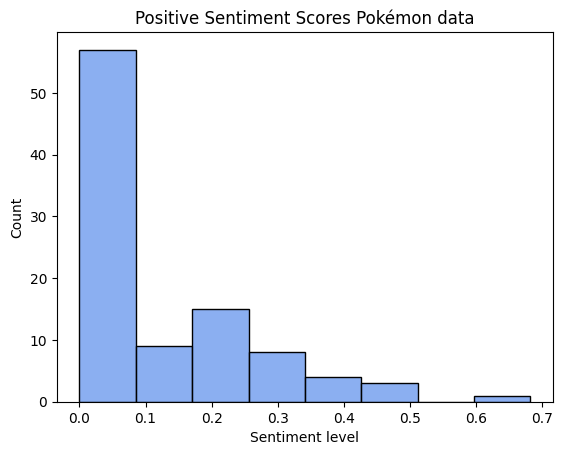

In [39]:
#os.system("pip install seaborn")
#os.system("pip install matplotlib")

# packages used for visualizations
import seaborn as sns
import matplotlib.pyplot as plt

#pokemon_data["title_sentiment_pos"] = pd.to_numeric(pokemon_data["title_sentiment_pos"], errors = "coerce")
sns.histplot(pokemon_data["title_sentiment_pos"], color = "cornflowerblue").set(title = "Positive Sentiment Scores Pokémon data", xlabel = "Sentiment level")
# save the plot as png
plt.savefig("sentiment_level_pos.png")

## Word Clouds

In [40]:
#os.system("pip install wordcloud")
#os.system("pip install PIL")

import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

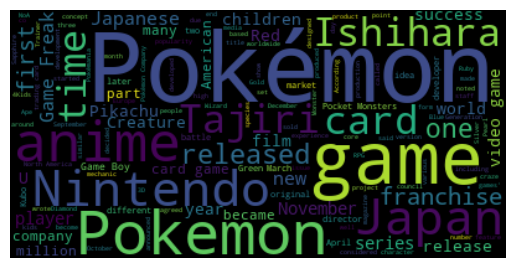

In [41]:
# use the data that we got from wikipedia
wordcloud_pokemon = WordCloud().generate(pokemon_text_whole)

plt.imshow(wordcloud_pokemon, interpolation = "bilinear")
plt.axis("off")
plt.savefig("wordcloud.png")
plt.show()

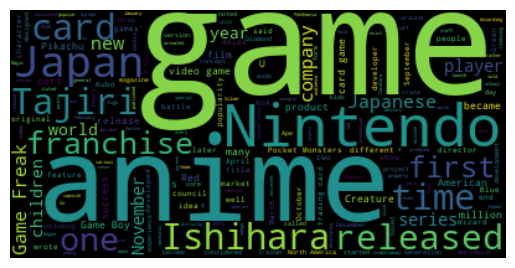

In [42]:
# ok, we get it, its about Pokémon
pokemon_text_trimmed = pokemon_text_whole.replace("Pokémon", "")
pokemon_text_trimmed = pokemon_text_trimmed.replace("Pokemon", "")


# create wordcloud
wordcloud_pokemon_trimmed = WordCloud().generate(pokemon_text_trimmed)

plt.imshow(wordcloud_pokemon_trimmed, interpolation = "bilinear")
plt.axis("off")
plt.savefig("wordcloud_2.png")
plt.show()

Methods like this can be used on any kind of text, which means also the descriptions we extracted before.